# BLIP: descripción automática de imágenes

En esta sección utilizamos un modelo de vision-language llamado BLIP.

Este tipo de modelos no clasifica imágenes en etiquetas rígidas, sino que genera descripciones en lenguaje natural a partir del contenido visual.

Esto nos permite pasar de:

- clasificación supervisada (CNN)
- detección de anomalías
- comprensión semántica de escenas

hacia una representación más rica del contenido visual.

# 1. Setup

In [ ]:
try:
    from google.colab import drive
    EN_COLAB = True
    !pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
    !pip install transformers==4.38.2
    !pip install pillow matplotlib requests
except:
    # Si corro en local, debo instalar estas dependencias al menos una vez
    EN_COLAB = False

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
import requests
from matplotlib import pyplot as plt

# 2. Cargar el modelo
La primera vez va a descargar varios MB.

In [ ]:
device = "cpu"

model_id = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(model_id)
model = BlipForConditionalGeneration.from_pretrained(model_id).to(device)
model.eval()

/home/pablo/miniconda3/envs/vision/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        )
      )
    )
    (post_layernorm): Laye

## 3. Inferencias

En esta sección utilizamos el modelo de visión-lenguaje para generar descripciones automáticas de imágenes.

A diferencia de un clasificador tradicional, el modelo no devuelve una etiqueta fija (por ejemplo *botella* o *lata*), sino una frase en lenguaje natural que resume el contenido visual.

Esto nos permite evaluar el comportamiento del modelo de forma más flexible y acercarnos a una interpretación semántica de las imágenes.

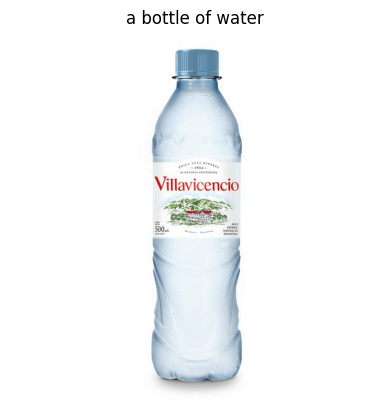

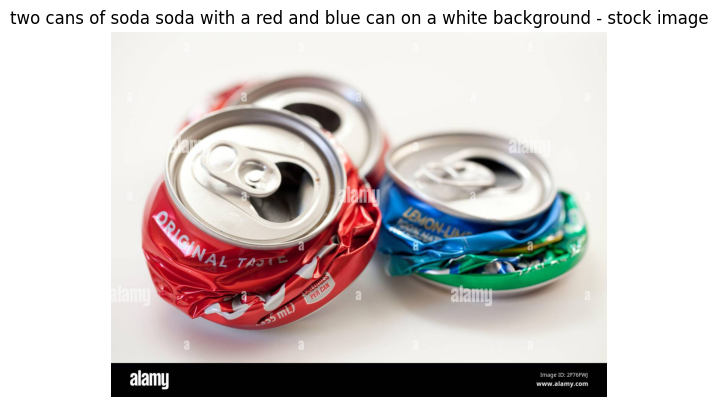

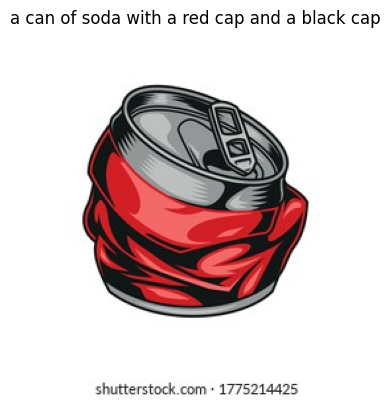

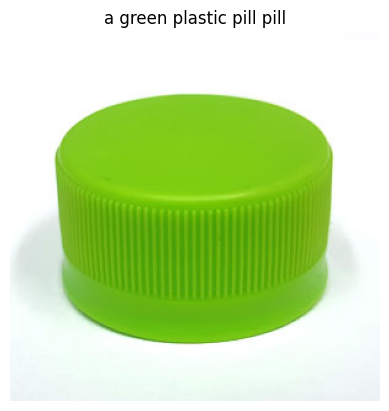

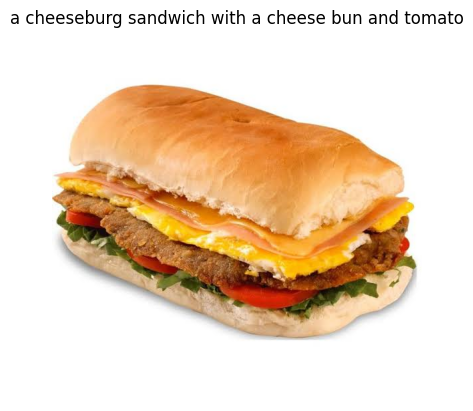

In [6]:
urls = [
    'https://statics.dinoonline.com.ar/imagenes/full_600x600_ma/3040004_f.jpg',
    'https://c8.alamy.com/compes/2f76fwj/latas-de-soda-de-aluminio-trituradas-para-reciclaje-ee-uu-2f76fwj.jpg',
    'https://www.shutterstock.com/image-vector/broken-aluminum-red-drink-can-260nw-1775214425.jpg',
    'https://mercoplast.com.py/img/productos/tapa-corta-para-botella-con-gas-2.jpg',
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR3nKa5Rx7Qhgqiphq9ylMkAqAcqadWtxhd-LbHVt6o4w&s=10'
]

for url in urls:
    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=30)
    caption = processor.decode(out[0], skip_special_tokens=True)

    plt.imshow(image)
    plt.axis("off")
    plt.title(caption)
    plt.show()
